# Análise Profunda: Master Dataset
Este notebook foca-se na análise detalhada do ficheiro `master_dataset.csv`, cruzando os dados financeiros, de urgências, internamentos, cirurgias e consultas para descobrir padrões e correlações.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
current_dir = os.getcwd()
pasta_raiz = os.path.dirname(current_dir) if os.path.basename(current_dir) == 'notebooks' else current_dir
file_path = os.path.join(pasta_raiz, 'data', 'processed', 'master_dataset.csv')

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Master Dataset loaded! Dimension: {df.shape[0]} rows and {df.shape[1]} columns.")
else:
    print("Error: Master Dataset not found at the expected path.")

Master Dataset loaded! Dimension: 11220 rows and 45 columns.


In [3]:
df.info()
display(df)
display(df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 11220 entries, 0 to 11219
Data columns (total 45 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   regiao                                                                       11220 non-null  str    
 1   instituicao                                                                  11220 non-null  str    
 2   ano                                                                          11220 non-null  int64  
 3   mes                                                                          11220 non-null  int64  
 4   ebitda                                                                       11220 non-null  float64
 5   gastos_operacionais                                                          11220 non-null  float64
 6   rendimentos_operacionais                         

,regiao,instituicao,ano,mes,ebitda,gastos_operacionais,rendimentos_operacionais,resultado_liquido,resultados_operacionais,urgencias_geral,...,informaticos,outros,total_geral,no_trabalhadores,taxa_de_utilizacao_global_de_consultas_medicas_1_ano,no_utentes_pelo_menos_1_consulta_medicas_presencial_ou_nao_presencial_1_ano,taxa_de_utilizacao_de_consultas_medicas_3_anos,no_utentes_com_pelo_menos_1_consulta_medica_em_3_anos,no_episodios_cirurgicos_ambulat_com_procedimentos_ambulatorizaveis,no_episodios_cirurgicos_ambulat_e_intern_com_proced_ambulatorizaveis
0,Alentejo,Administração Regional de Saúde do Alentejo,2016,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,85.0,747.0,755.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Alentejo,Administração Regional de Saúde do Alentejo,2016,2,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,85.0,746.0,754.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Alentejo,Administração Regional de Saúde do Alentejo,2016,3,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,85.0,747.0,755.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Alentejo,Administração Regional de Saúde do Alentejo,2016,4,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,89.0,745.0,753.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Alentejo,Administração Regional de Saúde do Alentejo,2016,5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,89.0,743.0,750.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11215,Serviços Centrais,"Serviços Partilhados do Ministério da Saúde, E...",2025,8,0.0,0.0,0.0,0.0,0.0,0.0,...,12.0,49.0,395.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11216,Serviços Centrais,"Serviços Partilhados do Ministério da Saúde, E...",2025,9,0.0,0.0,0.0,0.0,0.0,0.0,...,13.0,49.0,401.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11217,Serviços Centrais,"Serviços Partilhados do Ministério da Saúde, E...",2025,10,0.0,0.0,0.0,0.0,0.0,0.0,...,14.0,51.0,408.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11218,Serviços Centrais,"Serviços Partilhados do Ministério da Saúde, E...",2025,11,0.0,0.0,0.0,0.0,0.0,0.0,...,14.0,51.0,402.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,regiao,instituicao,ano,mes,ebitda,gastos_operacionais,rendimentos_operacionais,resultado_liquido,resultados_operacionais,urgencias_geral,...,informaticos,outros,total_geral,no_trabalhadores,taxa_de_utilizacao_global_de_consultas_medicas_1_ano,no_utentes_pelo_menos_1_consulta_medicas_presencial_ou_nao_presencial_1_ano,taxa_de_utilizacao_de_consultas_medicas_3_anos,no_utentes_com_pelo_menos_1_consulta_medica_em_3_anos,no_episodios_cirurgicos_ambulat_com_procedimentos_ambulatorizaveis,no_episodios_cirurgicos_ambulat_e_intern_com_proced_ambulatorizaveis
count,11220,11220,11220.000000,11220.000000,1.122000e+04,1.122000e+04,1.122000e+04,1.122000e+04,1.122000e+04,11220.000000,...,11220.000000,11220.000000,11220.000000,11220.000000,11220.000000,11220.000000,11220.000000,11220.000000,11220.000000,11220.000000
unique,6,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Lisboa e Vale do Tejo,"Administração Central do Sistema de Saúde, I.P.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3877,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2020.700624,6.506506,-5.247611e+06,4.668445e+07,4.053322e+07,-6.187772e+06,-6.217842e+06,25146.684581,...,5.209893,35.735561,1500.561676,1531.422727,29.840050,58237.898396,45.853950,90248.238057,955.389216,1123.458111
std,NaN,NaN,2.923931,3.454678,1.282423e+07,9.497079e+07,8.241555e+07,1.439508e+07,1.442277e+07,40084.842929,...,7.451807,109.116106,2178.263010,2192.168234,42.694662,82095.746762,62.159297,121307.229560,1696.461716,1958.057969
min,NaN,NaN,2016.000000,1.000000,-1.688819e+08,0.000000e+00,-6.411547e+06,-1.893682e+08,-1.886743e+08,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,2018.000000,4.000000,-5.194756e+06,0.000000e+00,0.000000e+00,-6.589148e+06,-6.634383e+06,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,2021.000000,7.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,0.000000,11.000000,496.000000,579.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,2023.000000,10.000000,0.000000e+00,5.710614e+07,4.967746e+07,0.000000e+00,0.000000e+00,41590.000000,...,9.000000,33.000000,2154.000000,2204.250000,57.327940,106483.250000,85.239170,175715.750000,1281.000000,1536.250000


## Columns and Institutions Analysis
Verification of the number of unique institutions and their statistics.

In [4]:
if 'instituicao' in df.columns:
    num_institutions = df['instituicao'].nunique()
    print(f"There are {num_institutions} different institutions in the dataset.\n")
    print("All institutions and their record counts:")
    with pd.option_context('display.max_rows', None):
        display(df['instituicao'].value_counts().to_frame(name='Record Count'))
else:
    print("Column 'instituicao' not found in the dataset.")

There are 100 different institutions in the dataset.

All institutions and their record counts:


,Record Count
instituicao,
"Administração Central do Sistema de Saúde, I.P.",240
"Infarmed - Autoridade Nacional do Medicamento e Produtos de Saúde, I.P.",240
Instituto Nacional de Emergência Médica,240
"Instituto Nacional de Saúde Doutor Ricardo Jorge, I.P.",240
"Instituto Português do Sangue e da Transplantação, I.P.",240
"Instituto para os Comportamentos Aditivos e as Dependências, I. P.",240
"Serviços Partilhados do Ministério da Saúde, E.P.E.",240
Secretaria-Geral do Ministério da Saúde,239
Ação Governativa,231


## Institutions by Region
Analysis of institutions grouped by region.

In [5]:
if 'regiao' in df.columns and 'instituicao' in df.columns:
    from IPython.display import display, Markdown
    display(Markdown("### Institutions by Region"))
    grouped = df.groupby('regiao')['instituicao'].unique()
    for regiao, insts in grouped.items():
        display(Markdown(f"**Region: {regiao}**"))
        display(Markdown("\n".join(f"- {inst}" for inst in sorted(insts))))
else:
    print("Columns 'regiao' or 'instituicao' not found in the dataset.")

### Institutions by Region

**Region: Alentejo**

- Administração Regional de Saúde do Alentejo
- Unidade Local de Saúde do Alentejo Central
- Unidade Local de Saúde do Alto Alentejo
- Unidade Local de Saúde do Baixo Alentejo
- Unidade Local de Saúde do Litoral Alentejano
- Área dos CSP da ULS Alentejo Central
- Área dos CSP da ULS Alto Alentejo
- Área dos CSP da ULS Baixo Alentejo
- Área dos CSP da ULS Litoral Alentejano

**Region: Algarve**

- Administração Regional de Saúde do Algarve
- Unidade Local de Saúde do Algarve
- Área dos CSP da ULS Algarve

...

- Administração Central do Sistema de Saúde, I.P.
- Administração Regional de Saúde de Lisboa e Vale do Tejo
- Ação Governativa
- Direção Executiva do Serviço Nacional de Saúde, I.P.
- Direção-Geral da Saúde
- Hospital de Cascais
- Infarmed - Autoridade Nacional do Medicamento e Produtos de Saúde, I.P.
- Inspeção-Geral das Atividades em Saúde
- Instituto Nacional de Emergência Médica
- Instituto Nacional de Saúde Doutor Ricardo Jorge, I.P.
- Instituto Português de Oncologia de Lisboa F. G.
- Instituto Português do Sangue e da Transplantação, I.P.
- Instituto para os Comportamentos Aditivos e as Dependências, I. P.
- Secretaria-Geral do Ministério da Saúde
- Serviços Partilhados do Ministério da Saúde, E.P.E.
- Unidade Local de Saúde da Arrábida
- Unidade Local de Saúde da Lezíria
- Unidade Local de Saúde de Almada-Seixal
- Unidade Local de Saúde de Amadora/Sintra
- Unidade Local de Saúde de Lisboa Ocidental
- Unidade Local de Saúde de Loures/Odivelas
- Unidade Local de Saúde de Santa Maria
- Unidade Local de Saúde de São José
- Unidade Local de Saúde do Arco Ribeirinho
- Unidade Local de Saúde do Estuário do Tejo
- Unidade Local de Saúde do Médio Tejo
- Unidade Local de Saúde do Oeste
- Área dos CSP da ULS Almada / Seixal
- Área dos CSP da ULS Amadora / Sintra
- Área dos CSP da ULS Arco Ribeirinho
- Área dos CSP da ULS Arrábida
- Área dos CSP da ULS Estuário do Tejo
- Área dos CSP da ULS Lezíria
- Área dos CSP da ULS Lisboa Ocidental
- Área dos CSP da ULS Loures / Odivelas
- Área dos CSP da ULS Médio Tejo
- Área dos CSP da ULS Oeste
- Área dos CSP da ULS Santa Maria
- Área dos CSP da ULS São José

**Region: Norte**

- Administração Regional de Saúde do Norte
- Instituto Português de Oncologia do Porto F. G.
- Unidade Local de Saúde da Póvoa de Varzim/Vila do Conde
- Unidade Local de Saúde de Barcelos/Esposende
- Unidade Local de Saúde de Braga
- Unidade Local de Saúde de Entre Douro e Vouga
- Unidade Local de Saúde de Matosinhos
- Unidade Local de Saúde de Santo António
- Unidade Local de Saúde de São João
- Unidade Local de Saúde de Trás-os-Montes e Alto Douro
- Unidade Local de Saúde de Vila Nova de Gaia/Espinho
- Unidade Local de Saúde do Alto Ave
- Unidade Local de Saúde do Alto Minho
- Unidade Local de Saúde do Médio Ave
- Unidade Local de Saúde do Nordeste
- Unidade Local de Saúde do Tâmega e Sousa
- Área dos CSP da ULS Alto Ave
- Área dos CSP da ULS Alto Minho
- Área dos CSP da ULS Barcelos / Esposende
- Área dos CSP da ULS Braga
- Área dos CSP da ULS Entre Douro e Vouga
- Área dos CSP da ULS Gaia / Espinho
- Área dos CSP da ULS Matosinhos
- Área dos CSP da ULS Médio Ave
- Área dos CSP da ULS Nordeste
- Área dos CSP da ULS Póvoa Varzim / Vila Conde
- Área dos CSP da ULS Santo António
- Área dos CSP da ULS São João
- Área dos CSP da ULS Trás-os-Montes Alto Douro
- Área dos CSP da ULS Tâmega e Sousa

**Region: Serviços Centrais**

- Administração Central do Sistema de Saúde, I.P.
- Ação Governativa
- Direção Executiva do Serviço Nacional de Saúde, I.P.
- Direção-Geral da Saúde
- Infarmed - Autoridade Nacional do Medicamento e Produtos de Saúde, I.P.
- Inspeção-Geral das Atividades em Saúde
- Instituto Nacional de Emergência Médica
- Instituto Nacional de Saúde Doutor Ricardo Jorge, I.P.
- Instituto Português do Sangue e da Transplantação, I.P.
- Instituto para os Comportamentos Aditivos e as Dependências, I. P.
- Secretaria-Geral do Ministério da Saúde
- Serviços Partilhados do Ministério da Saúde, E.P.E.

## 1. Evolução Temporal Anual
Vamos agregar os dados por ano para ver a evolução a nível nacional da produtividade hospitalar.

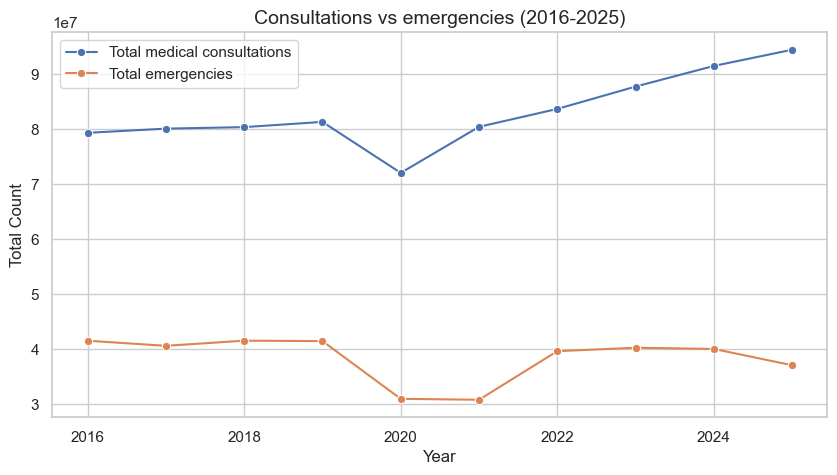

In [6]:
anual_evolution = df.groupby('ano').sum(numeric_only=True).reset_index()

plt.figure(figsize=(10, 5))
if 'no_de_consultas_medicas_total' in anual_evolution.columns:
    sns.lineplot(data=anual_evolution, x='ano', y='no_de_consultas_medicas_total', marker='o', label='Total medical consultations')
if 'total_urgencias' in anual_evolution.columns:
    sns.lineplot(data=anual_evolution, x='ano', y='total_urgencias', marker='o', label='Total emergencies')

plt.title('Consultations vs emergencies (2016-2025)', fontsize=14)
plt.ylabel('Total Count')
plt.xlabel('Year')
plt.legend()
plt.show()

## Visualização de valores em falta

<Figure size 1200x500 with 0 Axes>

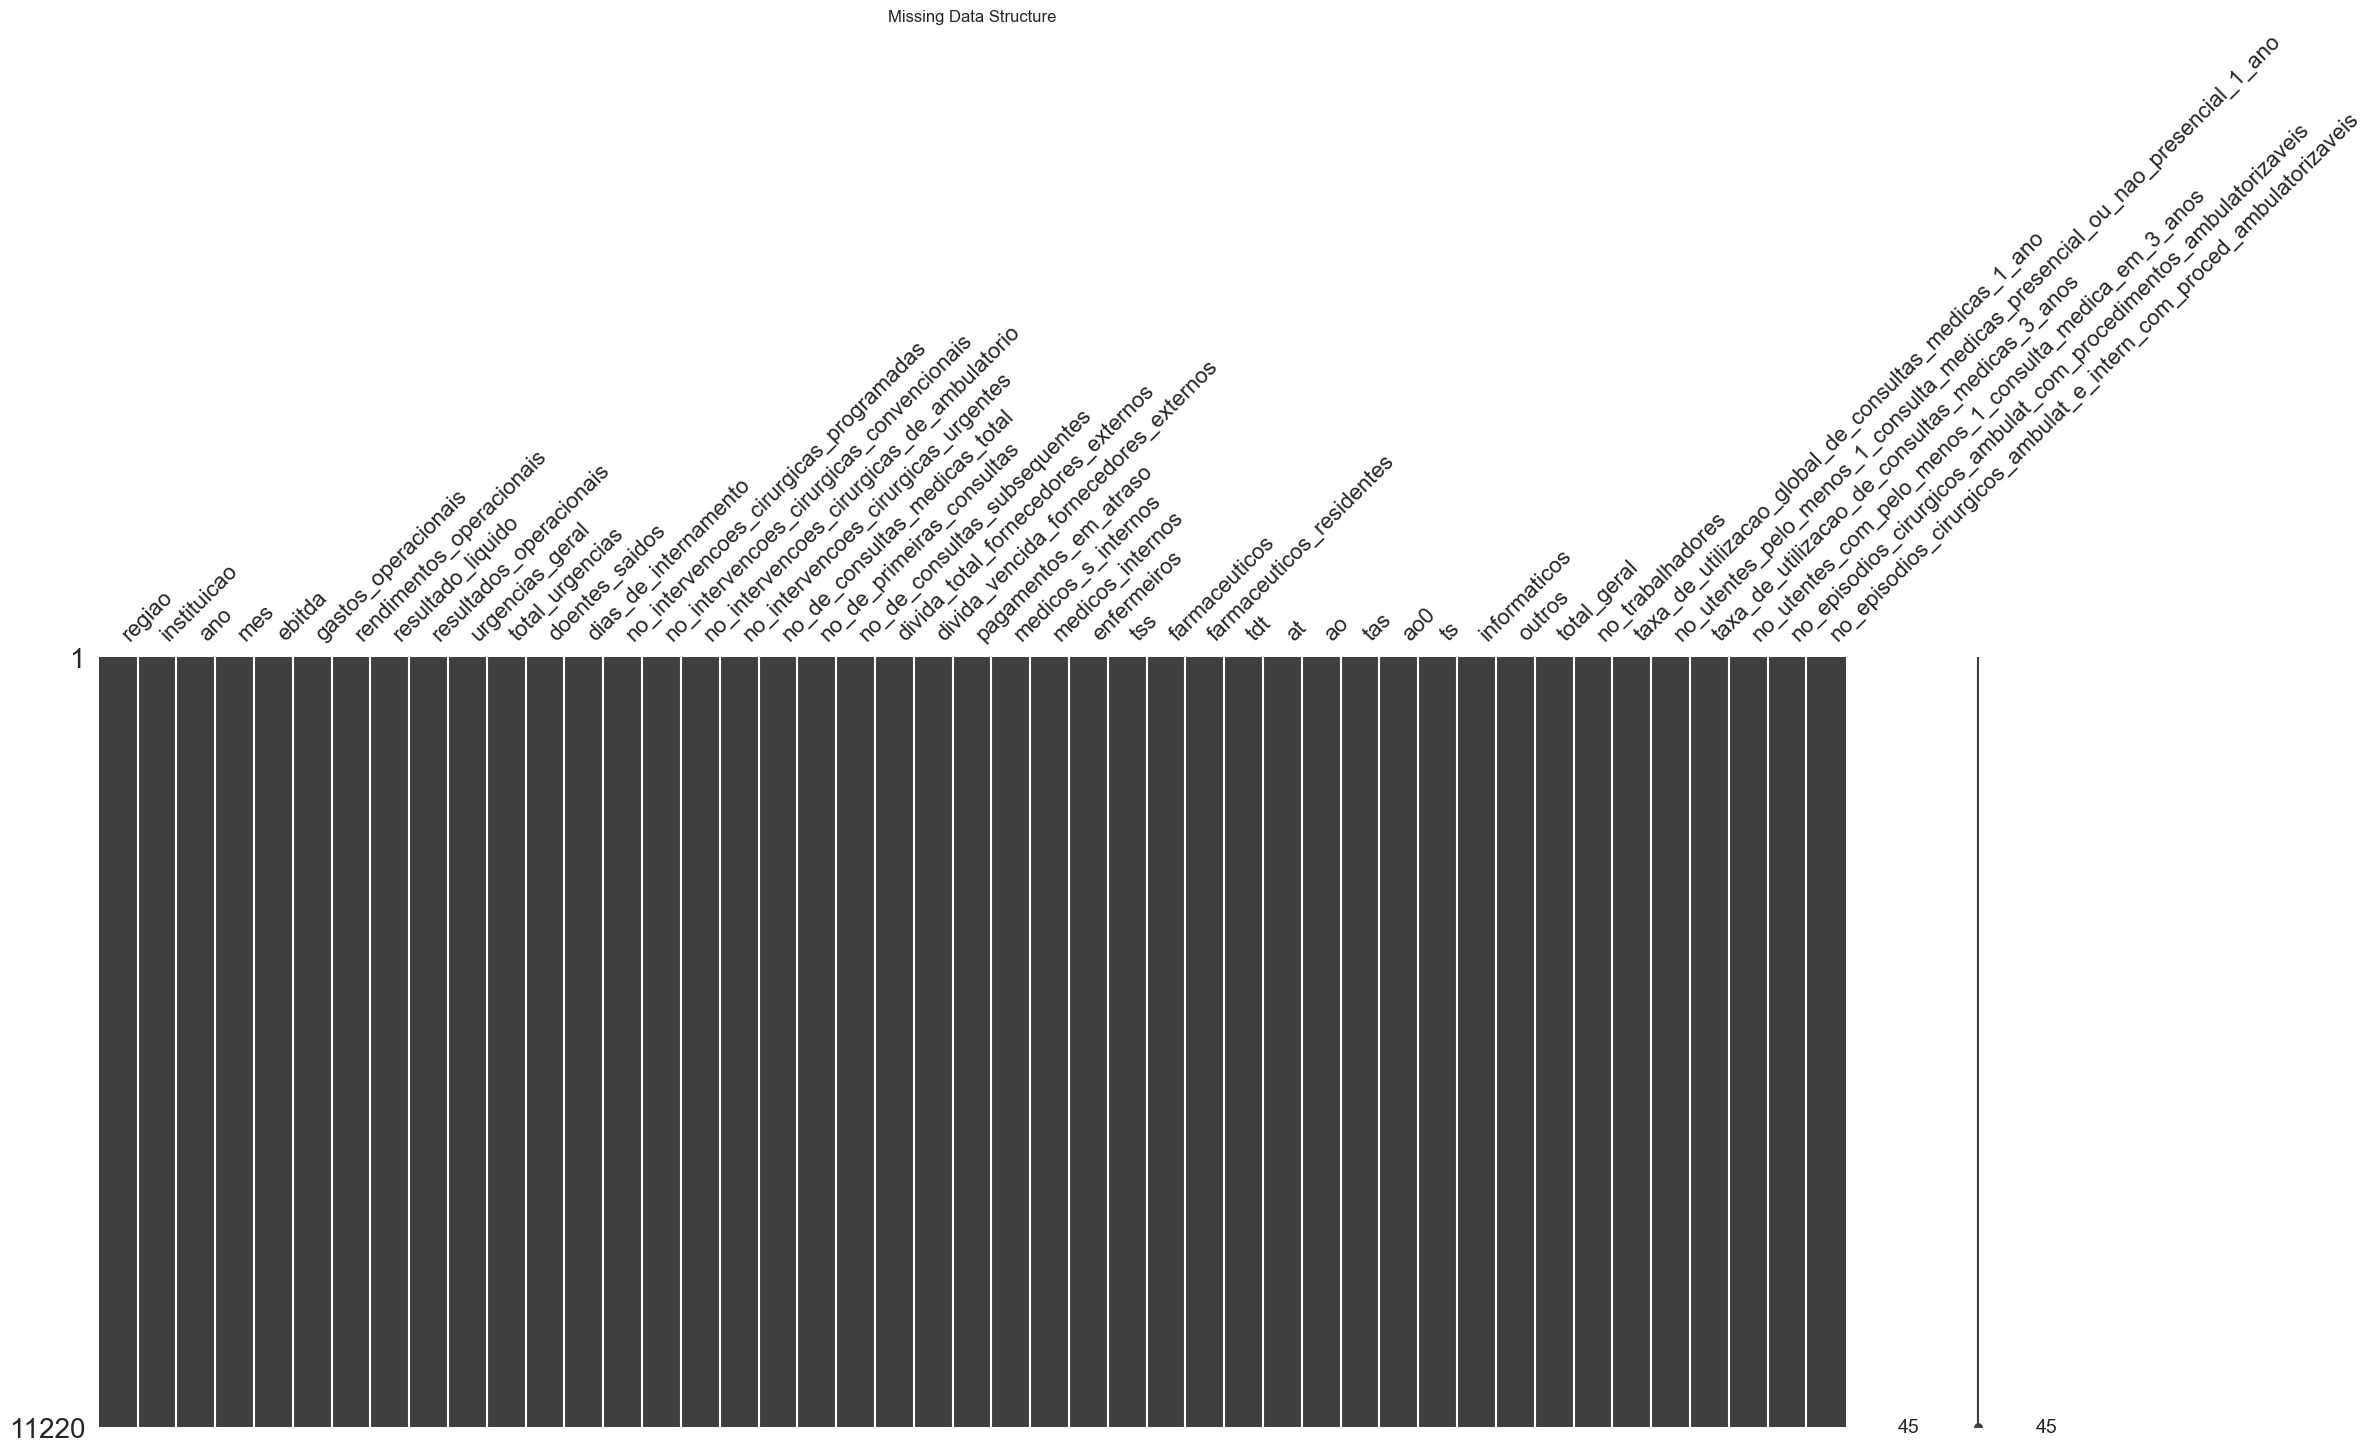

In [7]:
import missingno as msno

plt.figure(figsize=(12,5))
msno.matrix(df)
plt.title("Missing Data Structure")
plt.show()

## Melhores correlações

In [8]:

import numpy as np
import pandas as pd

num_df = df.select_dtypes(include=['float64','int64'])
corr_full = num_df.corr()

mask = np.triu(np.ones_like(corr_full, dtype=bool), k=1)

pairs_df = (
    corr_full.where(mask)            
            .stack()                 
            .rename('corr')          
            .reset_index()
            .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
)

pairs_df['abs_corr'] = pairs_df['corr'].abs()

pairs_sorted = pairs_df.sort_values('abs_corr', ascending=False)

top_n = 25
styled = (
    pairs_sorted.head(top_n)
    .style
    .format({'corr': '{:.6f}', 'abs_corr': '{:.6f}'})
    .background_gradient(cmap='RdYlBu_r', subset=['corr'])  
    .bar(subset=['abs_corr'], color='#1f77b4')              
    .hide(axis='index')
)
display(styled)



feature_1,feature_2,corr,abs_corr
resultado_liquido,resultados_operacionais,0.999686,0.999686
no_de_consultas_medicas_total,no_de_consultas_subsequentes,0.998732,0.998732
gastos_operacionais,rendimentos_operacionais,0.996729,0.996729
no_episodios_cirurgicos_ambulat_com_procedimentos_ambulatorizaveis,no_episodios_cirurgicos_ambulat_e_intern_com_proced_ambulatorizaveis,0.996611,0.996611
ebitda,resultado_liquido,0.996072,0.996072
ebitda,resultados_operacionais,0.996052,0.996052
no_intervencoes_cirurgicas_programadas,no_intervencoes_cirurgicas_de_ambulatorio,0.993039,0.993039
enfermeiros,total_geral,0.992199,0.992199
total_geral,no_trabalhadores,0.991622,0.991622
doentes_saidos,dias_de_internamento,0.991570,0.991570


## PCA

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaled = StandardScaler().fit_transform(num_df)

pca = PCA(n_components=5)
components = pca.fit_transform(scaled)

expl_var = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance %': pca.explained_variance_ratio_ * 100
})

display(expl_var)

plt.figure(figsize=(10,4))
sns.barplot(data=expl_var, x='PC', y='Explained Variance %')
plt.title("Explained Variance by Principal Components")
plt.show()

ModuleNotFoundError: No module named 'sklearn'

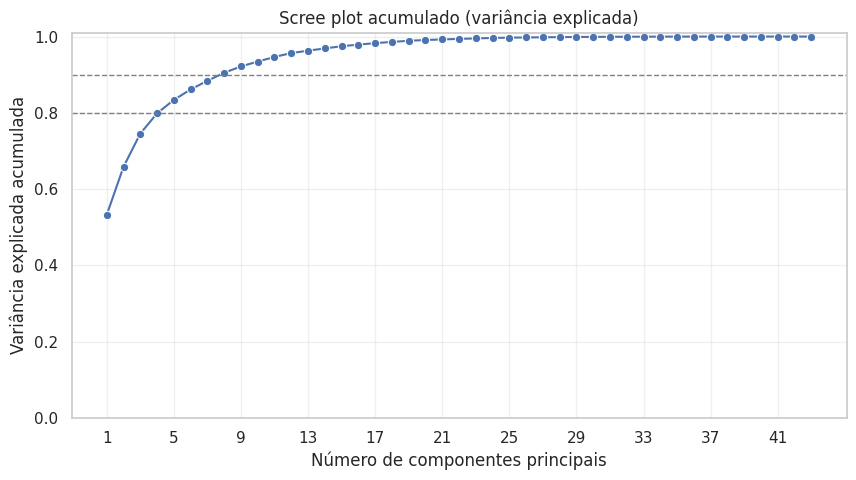

PCs para atingir ~80%: 5 | ~90%: 8


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seleciona apenas numérico
num_df = df.select_dtypes(include=['number']).copy()

# Escala e PCA com todos os componentes possíveis
X_scaled = StandardScaler().fit_transform(num_df)
pca_full = PCA().fit(X_scaled)

expl = pca_full.explained_variance_ratio_
cum_expl = np.cumsum(expl)

plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, len(cum_expl)+1), y=cum_expl, marker='o')
plt.axhline(0.80, color='grey', ls='--', lw=1)
plt.axhline(0.90, color='grey', ls='--', lw=1)
plt.title('Scree plot acumulado (variância explicada)')
plt.xlabel('Número de componentes principais')
plt.ylabel('Variância explicada acumulada')
plt.xticks(range(1, len(cum_expl)+1, max(1, len(cum_expl)//10)))
plt.ylim(0, 1.01)
plt.grid(True, alpha=0.3)
plt.show()

pc80 = np.argmax(cum_expl >= 0.80) + 1
pc90 = np.argmax(cum_expl >= 0.90) + 1
print(f"PCs para atingir ~80%: {pc80} | ~90%: {pc90}")


/tmp/ipykernel_897/1618437930.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


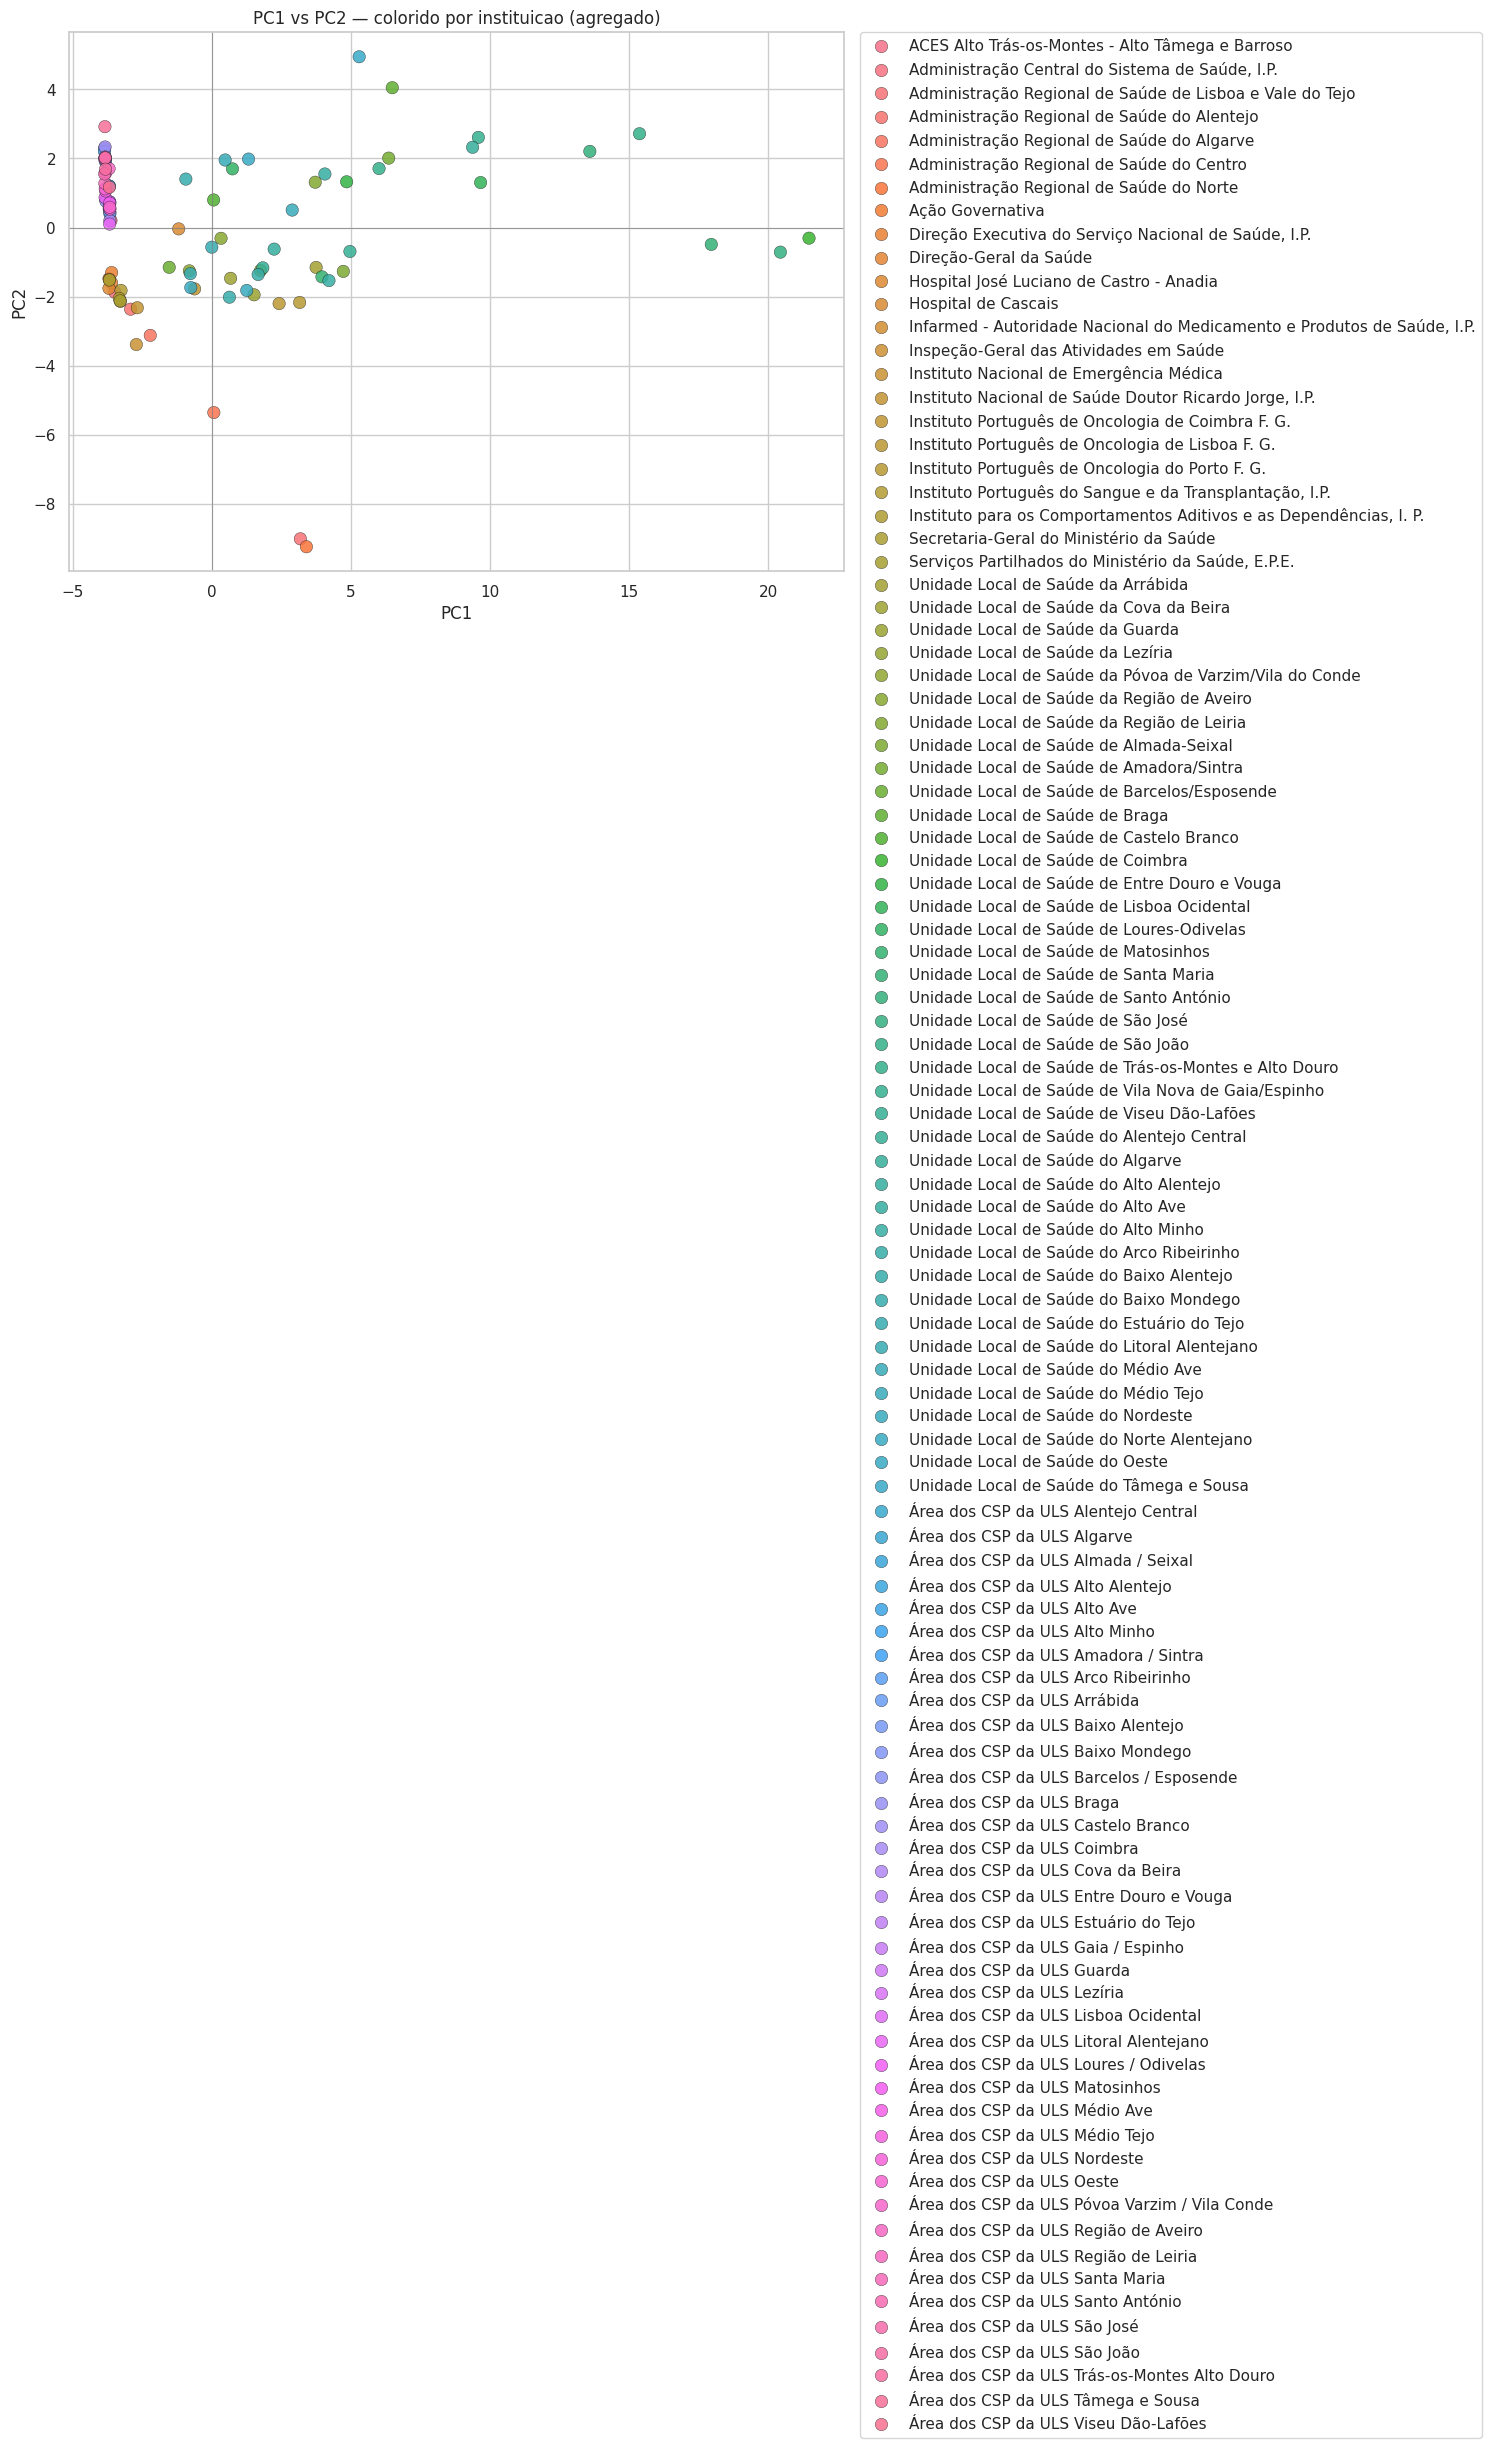

Top 10 variáveis que mais contribuem para PC1:


,PC1
ao,0.181127
gastos_operacionais,0.180086
rendimentos_operacionais,0.179862
tdt,0.178162
no_de_consultas_medicas_total,0.178013
dias_de_internamento,0.177794
no_de_consultas_subsequentes,0.177659
doentes_saidos,0.177343
no_de_primeiras_consultas,0.176990
no_intervencoes_cirurgicas_urgentes,0.176254



Top 10 variáveis que mais contribuem para PC2:


,PC2
taxa_de_utilizacao_de_consultas_medicas_3_anos,0.363634
taxa_de_utilizacao_global_de_consultas_medicas_1_ano,0.362992
no_utentes_pelo_menos_1_consulta_medicas_presencial_ou_nao_presencial_1_ano,0.360643
no_utentes_com_pelo_menos_1_consulta_medica_em_3_anos,0.358730
ts,-0.255932
at,-0.245068
tss,-0.236907
medicos_s_internos,-0.172787
ano,0.172694
outros,-0.169932


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

use_clusters = False   # <- muda para False para colorir por 'regiao' ou 'instituicao'
k = 5               


group_key = 'instituicao'  # 'instituicao' ou 'regiao'
df_grouped = df.groupby(group_key)[num_df.columns].mean() 

# PCA em dados agregados
X_scaled = StandardScaler().fit_transform(df_grouped)
pca2 = PCA(n_components=2).fit(X_scaled)
Z2 = pca2.transform(X_scaled)

plot_df = pd.DataFrame(Z2, columns=['PC1', 'PC2'], index=df_grouped.index).reset_index()
plot_df.rename(columns={group_key: 'grupo'}, inplace=True)

if use_clusters:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    plot_df['cluster'] = km.fit_predict(Z2).astype(str)
    hue_col = 'cluster'
    palette = 'tab10'
    title = f'PC1 vs PC2 — clusters KMeans (k={k}) agregados por {group_key}'
else:
    # colorir por grupo
    hue_col = 'grupo'
    palette = None
    title = f'PC1 vs PC2 — colorido por {group_key} (agregado)'

plt.figure(figsize=(10,7))
ax = sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue=hue_col, palette=palette, s=80, alpha=0.85, edgecolor='k', linewidth=0.3)
plt.title(title)
plt.axhline(0, color='grey', lw=0.5); plt.axvline(0, color='grey', lw=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

# Componentes que mais pesam em PC1 e PC2 (top 10 por valor absoluto)
loadings = pd.DataFrame(pca2.components_, columns=df_grouped.columns, index=['PC1','PC2']).T
top10_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(10)
top10_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(10)
print("Top 10 variáveis que mais contribuem para PC1:")
display(loadings.loc[top10_pc1.index][['PC1']].sort_values(by='PC1', key=lambda s: s.abs(), ascending=False))
print("\nTop 10 variáveis que mais contribuem para PC2:")
display(loadings.loc[top10_pc2.index][['PC2']].sort_values(by='PC2', key=lambda s: s.abs(), ascending=False))

## Análise de Outliers

,outliers,total,percent
farmaceuticos,2516,11331,22.2%
pagamentos_em_atraso,1751,11331,15.5%
ebitda,1620,11331,14.3%
resultado_liquido,1485,11331,13.1%
resultados_operacionais,1479,11331,13.1%
farmaceuticos_residentes,1423,11331,12.6%
medicos_internos,1230,11331,10.9%
no_intervencoes_cirurgicas_de_ambulatorio,1154,11331,10.2%
no_episodios_cirurgicos_ambulat_com_procedimentos_ambulatorizaveis,1143,11331,10.1%
rendimentos_operacionais,1134,11331,10.0%


/tmp/ipykernel_897/3560501019.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outlier_df.head(top_n).reset_index(),


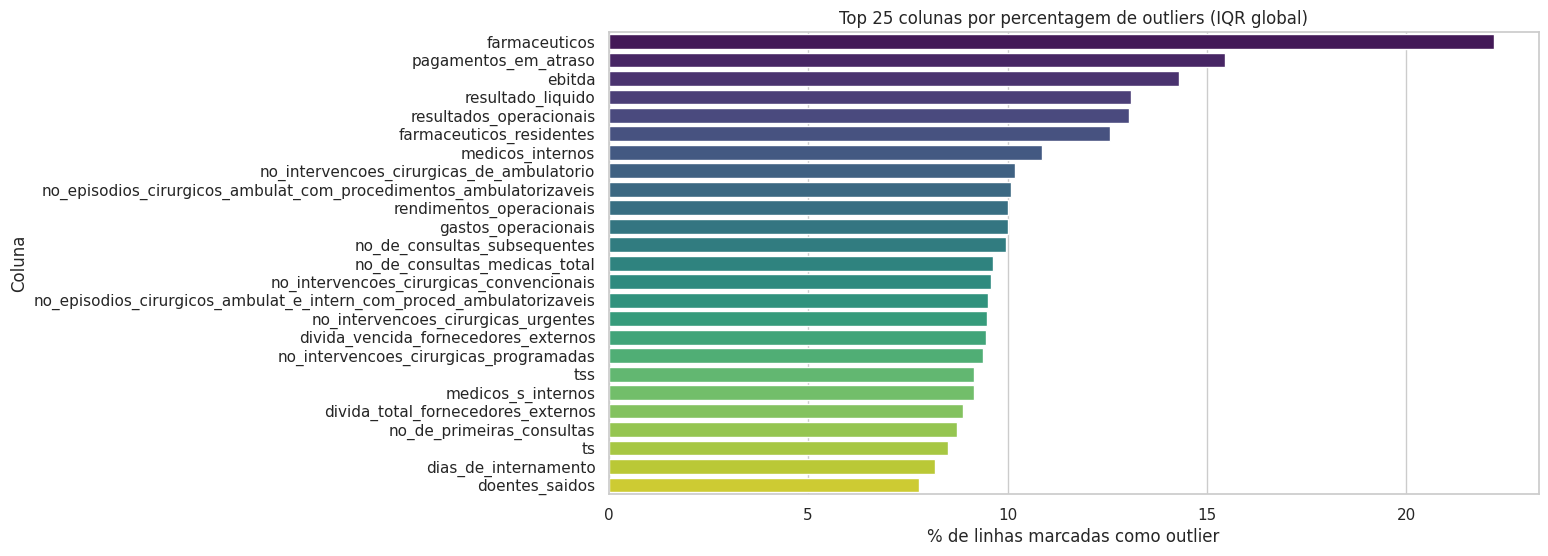

In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df.select_dtypes(include=['number']).copy()

def iqr_outlier_mask(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

outlier_counts = {}
for col in num_df.columns:
    mask = iqr_outlier_mask(num_df[col])
    outlier_counts[col] = mask.sum()

outlier_df = (pd.Series(outlier_counts, name='outliers')
                .to_frame()
                .assign(total=len(num_df))
                .assign(percent=lambda d: 100*d['outliers']/d['total'])
                .sort_values('percent', ascending=False))

display(outlier_df.head(20).style.format({'percent': '{:.1f}%'}))

# Gráfico
top_n = 25
plt.figure(figsize=(12,6))
sns.barplot(data=outlier_df.head(top_n).reset_index(),
            x='percent', y='index', palette='viridis')
plt.xlabel('% de linhas marcadas como outlier')
plt.ylabel('Coluna')
plt.title(f'Top {top_n} colunas por percentagem de outliers (IQR global)')
plt.show()


In [ ]:

group_col = 'instituicao'  # ou 'regiao'

group_counts = {}
for col in num_df.columns:
    if col in {'ano','mes'}: 
        continue
    cnt = 0
    total = 0
    for g, gdf in df.groupby(group_col, as_index=False):
        s = gdf[col].dropna()
        if len(s) < 8:  # pouco dados → ignora (IQR instável)
            continue
        mask = iqr_outlier_mask(s)
        cnt += mask.sum()
        total += len(s)
    group_counts[col] = (cnt, total)

group_outlier_df = (pd.DataFrame(group_counts, index=['outliers','total']).T
                      .assign(percent=lambda d: 100*d['outliers']/d['total'])
                      .sort_values('percent', ascending=False))

display(group_outlier_df.style.format({'percent':'{:.1f}%'}))


,outliers,total,percent
outros,1319,11331,11.6%
ts,1218,11331,10.7%
informaticos,1071,11331,9.5%
medicos_s_internos,869,11331,7.7%
at,857,11331,7.6%
total_geral,669,11331,5.9%
ao0,645,11331,5.7%
no_trabalhadores,640,11331,5.6%
ao,599,11331,5.3%
enfermeiros,583,11331,5.1%


## Sazonalidade Mensal

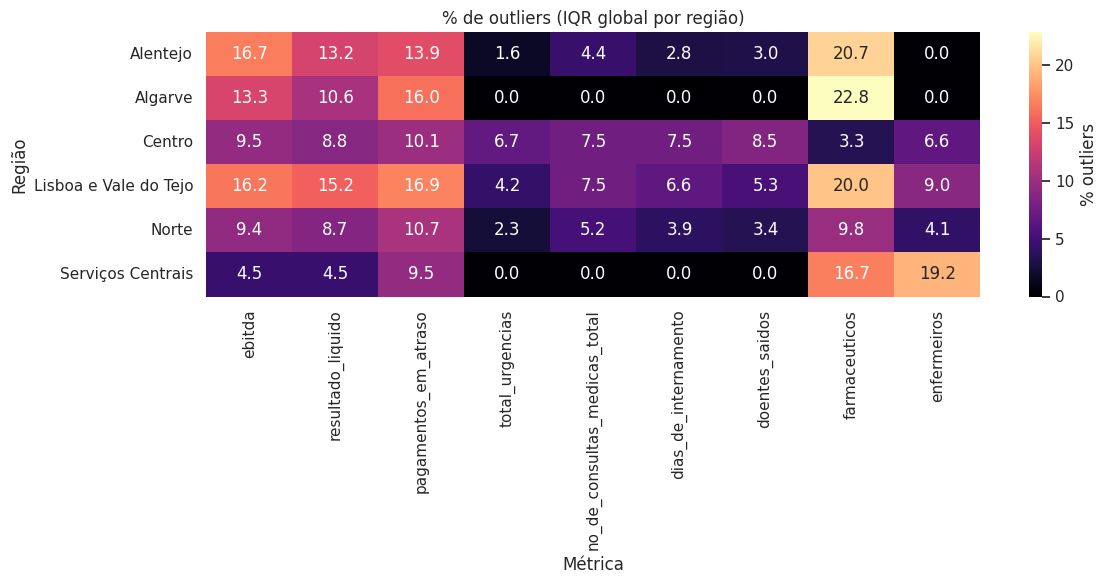

In [ ]:

metrics = ['ebitda','resultado_liquido','pagamentos_em_atraso','total_urgencias',
           'no_de_consultas_medicas_total','dias_de_internamento','doentes_saidos',
           'farmaceuticos','enfermeiros']
metrics = [m for m in metrics if m in df.columns]

def outlier_rate_by_region(col):
    rates = []
    for r, g in df.groupby('regiao'):
        s = g[col].dropna()
        if len(s) < 12:
            rates.append(np.nan)
            continue
        m = iqr_outlier_mask(s)
        rates.append(100*m.sum()/len(s))
    return rates

heat = pd.DataFrame({m: outlier_rate_by_region(m) for m in metrics},
                    index=sorted(df['regiao'].unique()))

plt.figure(figsize=(12, 6))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='magma', cbar_kws={'label':'% outliers'})
plt.title('% de outliers (IQR global por região)')
plt.xlabel('Métrica'); plt.ylabel('Região')
plt.tight_layout(); plt.show()


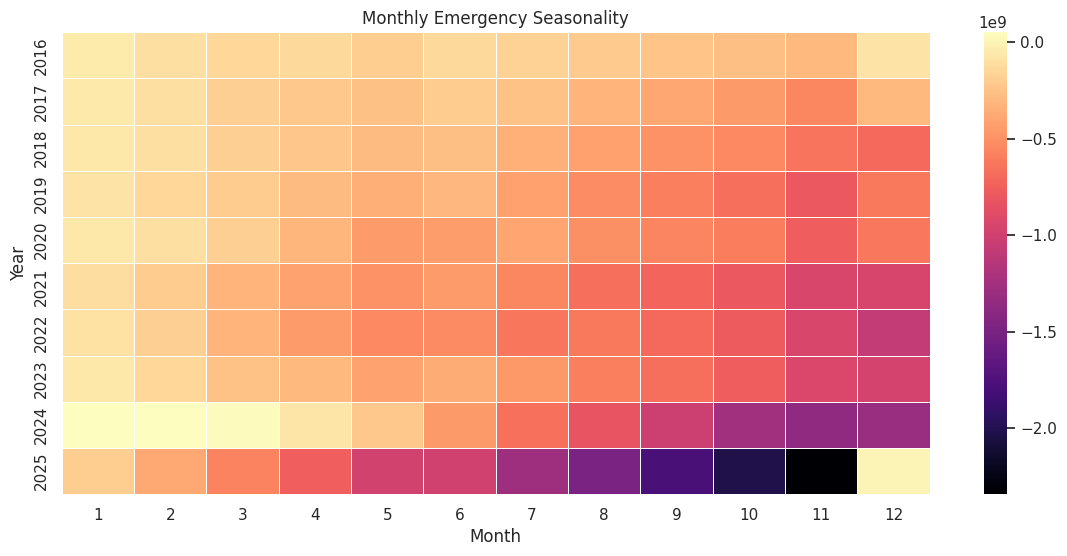

In [ ]:
df['date'] = pd.to_datetime(df['ano'].astype(str) + '-' + df['mes'].astype(str) + '-01')

monthly = df.groupby(['ano','mes'])['total_urgencias'].sum().unstack()

plt.figure(figsize=(14,6))
sns.heatmap(monthly, cmap='magma', linewidths=.5)
plt.title("Monthly Emergency Seasonality")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

## Ranking de Perfomance de Instituição

In [ ]:
kpis = [
    'resultado_liquido',
    'ebitda',
    'no_de_consultas_medicas_total',
    'total_urgencias',
    'dias_de_internamento',
]

ranking = df.groupby('instituicao')[kpis].mean().sort_values(by='resultado_liquido', ascending=False)
display(ranking)

,resultado_liquido,ebitda,no_de_consultas_medicas_total,total_urgencias,dias_de_internamento
instituicao,,,,,
Instituto Nacional de Emergência Médica,3.413706e+05,5.732313e+05,0.000000,0.000000,0.000000
"Direção Executiva do Serviço Nacional de Saúde, I.P.",1.648049e+05,1.673283e+05,0.000000,0.000000,0.000000
Administração Regional de Saúde de Lisboa e Vale do Tejo,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
Administração Regional de Saúde do Alentejo,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
ACES Alto Trás-os-Montes - Alto Tâmega e Barroso,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
...,...,...,...,...,...
Unidade Local de Saúde de Santo António,-2.690946e+07,-2.228671e+07,407592.550000,76496.625000,164571.216667
Unidade Local de Saúde de Lisboa Ocidental,-3.272605e+07,-2.786635e+07,253838.658333,76260.600000,122748.658333
Unidade Local de Saúde de Coimbra,-4.143724e+07,-3.541454e+07,500624.458333,145953.058333,256823.975000


## 🌍 Regional Productivity Comparison

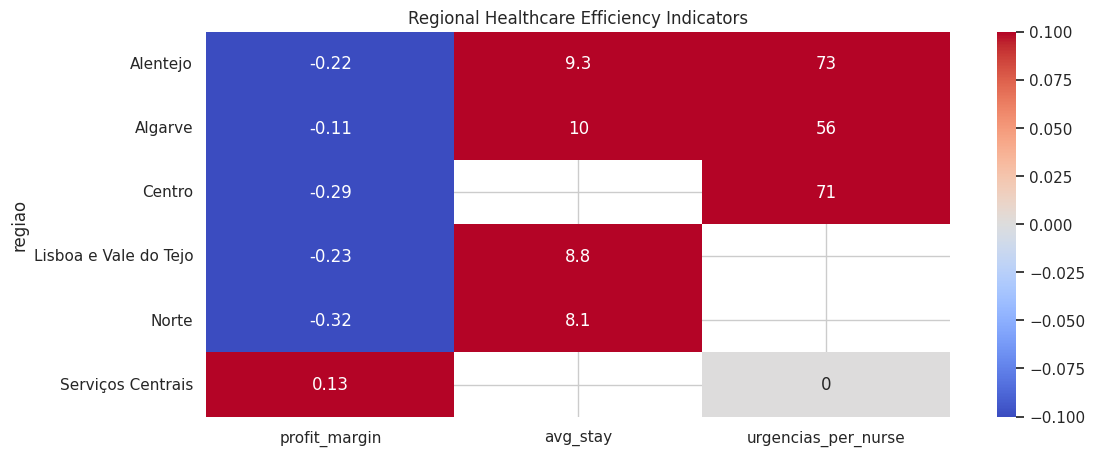

In [ ]:
region_eff = df.groupby('regiao')[['profit_margin', 'avg_stay', 'urgencias_per_nurse']].mean()

plt.figure(figsize=(12,5))
sns.heatmap(region_eff, annot=True, cmap='coolwarm')
plt.title("Regional Healthcare Efficiency Indicators")
plt.show()